[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter3_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 3: Structural VAR and local projections

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 3; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- VAR, identification and inference tools of Chapter 3 (`var_ols`, `irf`, `fevd`, `bq_impact`, `bootstrap_var`, `proxy_irf`, `proxy_mbb`, `lp`, `lp_iv`), data loaders and the functions of the solved tasks.

In [ ]:
import io
import zipfile
import urllib.error
SEED = 2026
RAMEY_MON = 'https://econweb.ucsd.edu/~vramey/research/Ramey_HOM_monetary.zip'
RAMEY_RZ = 'https://econweb.ucsd.edu/~vramey/research/Ramey_Zubairy_replication_codes.zip'
EIA_INTL = 'https://api.eia.gov/bulk/INTL.zip'
EIA_PROD = 'INTL.57-1-WORL-TBPD.M'
EIA_MER9 = 'https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T09.01'
EA_Y1 = ('YC', 'B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y')
JK_ECB = 'https://raw.githubusercontent.com/marekjarocinski/jkshocks_update_ecb/main/shocks_ecb_mpd_me_m.csv'
RO_IP = ('sts_inpr_m', 'M.PRD.B-D.SCA.I21.RO')
EA_IP = ('sts_inpr_m', 'M.PRD.B-D.SCA.I21.EA20')
RO_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.RO')
EA_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.EA')
RO_R3M = ('irt_st_m', 'M.IRT_M3.RO')
EA_R3M = ('irt_st_m', 'M.IRT_M3.EA')
RO_START = '2005-08-01'
CEE = {'vars': ['lip', 'unemp', 'lcpi', 'lpcom', 'ffr', 'lnbr', 'ltr', 'lm1'], 'p': 12, 'start': '1965-01-01', 'end': '1995-06-01', 'H': 48, 'shock': 'ffr'}
KIL = {'p': 24, 'start': '1973-01-01', 'end': '2007-12-01', 'H': 18}
BQ = {'p': 8, 'start': '1948-04-01', 'end': '1987-10-01', 'brk': '1974-01-01', 'H': 40}
UHL = {'vars': ['lip', 'lcpi', 'lpcom', 'ffr', 'lnbr', 'ltr'], 'p': 12, 'start': '1965-01-01', 'end': '2003-12-01', 'K': 5, 'H': 60}
GK = {'vars': ['gs1', 'lip', 'lcpi', 'ebp'], 'p': 12, 'start': '1979-07-01', 'end': '2012-06-01', 'zstart': '1991-01-01', 'H': 48}
LPGK = {'p': 2, 'start': '1990-01-01', 'end': '2012-06-01', 'H': 48}
RZ = {'p': 4, 'H': 20, 'thr': 6.5, 'start': 1889.0}
RO = {'p': 2, 'H': 36, 'end': '2026-07-01'}
NBOOT = 500
RO_VARS = ['ip_ea', 'p_ea', 'r_ea', 'ip_ro', 'p_ro', 'r_ro', 'fx']
PSI = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.3, 0.2, 0.1])
KIL_SIGN = np.diag([-1.0, 1.0, 1.0])
_FILES = {}
SIG = np.array([[4.0, 1.0], [1.0, 2.0]])
A1M = np.array([[0.5, 0.0], [0.2, 0.4]])
A21 = -0.2
A3A = np.array([[0.2, -0.3], [0.1, 0.6]])
A3S = np.array([[1.0, -0.2], [-0.2, 0.5]])
A4S = np.array([[1.0, 0.3], [0.3, 0.5]])
A5C = np.array([0.02, -0.006, 0.01])
A6 = {'rho': 0.9, 'h': 4, 'T': 200}
A8B = np.array([[1.0, 0.5], [0.3, 1.0]])
A8D1 = np.diag([1.0, 1.0])
A8D2 = np.diag([4.0, 1.0])


def read_ecb(flow, key, start=None):
    """One series from the ECB Data Portal (public SDMX REST API, CSV), e.g. the monthly USD/EUR reference rate:
        read_ecb('EXR', 'M.USD.EUR.SP00.A')
    or the euro-area HICP annual rate of change: read_ecb('ICP', 'M.U2.N.000000.4.ANR')."""
    url = (f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}?format=csvdata'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('ecb', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{flow}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder ATS_CACHE."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(5):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=300).read()
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 4:
                raise
            time.sleep(10 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def zip_member(url, name):
    """One file from a public zip archive."""
    z = zipfile.ZipFile(io.BytesIO(get_bytes(url)))
    m = [f for f in z.namelist() if f.endswith(name)][0]
    return z.read(m)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def lagmat(Y, p):
    """Regressor matrix [Y_{t-1}, ..., Y_{t-p}] for t = p..T-1 (rows), and the left-hand side Y_t."""
    Y = np.asarray(Y, float)
    T = len(Y)
    X = np.hstack([Y[p - j - 1:T - j - 1] for j in range(p)])
    return Y[p:], X


def var_ols(Y, p, const=True, exog=None):
    """OLS of a VAR(p) with optional constant and exogenous regressors (aligned with Y). Returns a dict with the lag
    matrices A (p x n x n), the deterministic coefficients, residuals U (T-p x n) and Sigma = U'U/(T - p - k)."""
    Yt, X = lagmat(Y, p)
    n = Yt.shape[1]
    D = []
    if const:
        D.append(np.ones((len(Yt), 1)))
    if exog is not None:
        D.append(np.asarray(exog, float)[p:])
    Xf = np.hstack([X] + D) if D else X
    B = np.linalg.lstsq(Xf, Yt, rcond=None)[0]
    U = Yt - Xf @ B
    k = Xf.shape[1]
    A = np.stack([B[j * n:(j + 1) * n].T for j in range(p)])
    return dict(A=A, det=B[n * p:], U=U, Sigma=U.T @ U / (len(Yt) - k), Sigma_ml=U.T @ U / len(Yt), X=Xf, B=B,
                Y=np.asarray(Y, float), p=p, const=const, exog=exog)


def companion(A):
    p, n, _ = A.shape
    F = np.zeros((n * p, n * p))
    F[:n] = np.hstack(list(A))
    F[n:, :-n] = np.eye(n * (p - 1))
    return F


def max_root(A):
    return float(np.max(np.abs(np.linalg.eigvals(companion(A)))))


def ma_coefs(A, H):
    """Reduced-form MA coefficients Phi_0..Phi_H (Phi_0 = I)."""
    p, n, _ = A.shape
    Phi = np.zeros((H + 1, n, n))
    Phi[0] = np.eye(n)
    for h in range(1, H + 1):
        Phi[h] = sum(A[j] @ Phi[h - j - 1] for j in range(min(p, h)))
    return Phi


def irf(A, B0, H):
    """Structural impulse responses Theta_h = Phi_h B0 (H+1 x n x n): [h, response, shock]."""
    return np.einsum('hij,jk->hik', ma_coefs(A, H), B0)


def fevd(Theta):
    """Forecast error variance decomposition: share of shock k in the h-step error variance of variable i."""
    c = np.cumsum(Theta ** 2, axis=0)
    return c / c.sum(axis=2, keepdims=True)


def simulate_var(A, det, Xdet, U, Y0):
    """Recursive simulation of a VAR from initial values Y0 (p x n) with residuals U and deterministic terms."""
    p, n, _ = A.shape
    T = len(U)
    Y = np.zeros((T + p, n))
    Y[:p] = Y0
    for t in range(T):
        y = sum(A[j] @ Y[p + t - j - 1] for j in range(p)) + U[t]
        if Xdet is not None:
            y = y + Xdet[t] @ det
        Y[p + t] = y
    return Y


def bootstrap_var(m, ident, H, B=NBOOT, kind='residual', seed=SEED, bias=None):
    """Bootstrap distribution of structural responses. ident(A, Sigma, U) -> B0. kind: 'residual' (i.i.d. resampling
    of residuals) or 'wild' (recursive-design wild bootstrap, Rademacher weights; Goncalves and Kilian 2004).
    bias: optional bias of A (Kilian 1998) subtracted from each bootstrap estimate."""
    rng = np.random.default_rng(seed)
    A, U, p, Y = m['A'], m['U'], m['p'], m['Y']
    n = A.shape[1]
    Xdet = m['X'][:, n * p:] if m['X'].shape[1] > n * p else None
    det = m['det'] if Xdet is not None else None
    Uc = U - U.mean(axis=0)
    out = np.zeros((B, H + 1, n, n))
    Abar = np.zeros_like(A)
    for b in range(B):
        Ub = Uc[rng.integers(0, len(U), len(U))] if kind == 'residual' else U * rng.choice([-1.0, 1.0], (len(U), 1))
        s = rng.integers(0, len(Y) - p + 1)
        Yb = simulate_var(A, det, Xdet, Ub, Y[s:s + p])
        mb = var_ols(Yb, p, const=m['const'], exog=None if m['exog'] is None else m['exog'])
        Ab = mb['A']
        Abar += Ab / B
        if bias is not None:
            Ab = shrink_bias(Ab, bias)
        out[b] = irf(Ab, ident(Ab, mb['Sigma'], mb['U']), H)
    return out, Abar


def shrink_bias(A, bias):
    """Kilian (1998): subtract the bias, shrinking the correction until the corrected VAR is stationary."""
    d = 1.0
    while d > 0:
        Ac = A - d * bias
        if max_root(Ac) < 1:
            return Ac
        d -= 0.01
    return A


def kilian_bias(m, B=200, seed=SEED + 1):
    """Bootstrap estimate of the small-sample bias of the VAR slope coefficients (Kilian 1998, first stage)."""
    _, Abar = bootstrap_var(m, lambda A, S, U: np.eye(A.shape[1]), 0, B=B, seed=seed)
    return Abar - m['A']


def bands(draws, lev=(0.05, 0.95)):
    return np.quantile(draws, lev[0], axis=0), np.quantile(draws, lev[1], axis=0)


def chol(A, S, U):
    return np.linalg.cholesky(S)


def band_plot(ax, h, mid, lo, hi, color, label, lo2=None, hi2=None):
    """Point estimate with a shaded band (and an optional inner band)."""
    ax.fill_between(h, lo, hi, color=color, alpha=0.15, lw=0, label='_band')
    if lo2 is not None:
        ax.fill_between(h, lo2, hi2, color=color, alpha=0.28, lw=0, label='_band2')
    ax.plot(h, mid, color=color, lw=1.8, label=label)
    ax.axhline(0, color=st.DarkText, lw=0.6)


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def nw_se(X, e, L):
    """Newey-West (Bartlett) covariance of OLS coefficients with L lags."""
    XtXi = np.linalg.inv(X.T @ X)
    g = X * e[:, None]
    S = g.T @ g
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        G = g[l:].T @ g[:-l]
        S += w * (G + G.T)
    return XtXi @ S @ XtXi


def lp(y, x, W, H, nw=True, lag_aug=False):
    """Local projections (Jorda 2005): y_{t+h} on x_t and controls W_t (rows aligned with t), h = 0..H.
    Standard errors: Newey-West with h + 1 lags, or Eicker-Huber-White when lag_aug (Montiel Olea and
    Plagborg-Moller 2021: the controls include one extra lag)."""
    y, x, W = np.asarray(y, float), np.asarray(x, float), np.asarray(W, float)
    b, se = np.full(H + 1, np.nan), np.full(H + 1, np.nan)
    for h in range(H + 1):
        yy = y[h:]
        X = np.column_stack([x[:len(x) - h], np.ones(len(x) - h), W[:len(W) - h]])
        ok = ~np.isnan(yy) & ~np.isnan(X).any(axis=1)
        Xo, yo = X[ok], yy[ok]
        bh = np.linalg.lstsq(Xo, yo, rcond=None)[0]
        e = yo - Xo @ bh
        V = nw_se(Xo, e, 0 if lag_aug else h + 1)
        b[h], se[h] = bh[0], np.sqrt(V[0, 0])
    return b, se


def tsls(y, x, z, W):
    """Two-stage least squares of y on x (instrumented by z) with exogenous controls W; returns beta, residuals, design."""
    Z = np.column_stack([z, np.ones(len(z)), W])
    X = np.column_stack([x, np.ones(len(x)), W])
    Pz = Z @ np.linalg.lstsq(Z, X, rcond=None)[0]
    b = np.linalg.lstsq(Pz, y, rcond=None)[0]
    return b, y - X @ b, Pz


def lp_iv(y, x, z, W, H, cum=False):
    """LP-IV (Stock and Watson 2018): y_{t+h} on x_t instrumented by z_t, controls W_t; Newey-West SE (h + 1 lags).
    cum=True: cumulative y_{t..t+h} on cumulative x_{t..t+h} (the multiplier of Ramey and Zubairy 2018)."""
    y, x, z, W = (np.asarray(a, float) for a in (y, x, z, W))
    b, se, F = np.full(H + 1, np.nan), np.full(H + 1, np.nan), np.full(H + 1, np.nan)
    T = len(y)
    for h in range(H + 1):
        if cum:
            yy = np.array([y[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
            xx = np.array([x[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
        else:
            yy = np.r_[y[h:], np.full(h, np.nan)]
            xx = x
        D = np.column_stack([yy, xx, z, W])
        ok = ~np.isnan(D).any(axis=1)
        bh, e, Pz = tsls(yy[ok], xx[ok], z[ok], W[ok])
        V = nw_se(Pz, e, h + 1)
        b[h], se[h] = bh[0], np.sqrt(V[0, 0])
        Xf = np.column_stack([z[ok], np.ones(ok.sum()), W[ok]])
        g = np.linalg.lstsq(Xf, xx[ok], rcond=None)[0]
        ef = xx[ok] - Xf @ g
        Vf = nw_se(Xf, ef, h + 1)
        F[h] = g[0] ** 2 / Vf[0, 0]
    return b, se, F


def lags_of(df, cols, p, start=1):
    """Lags start..p of the columns `cols` of a DataFrame, as one array."""
    return np.column_stack([df[c].shift(j).values for c in cols for j in range(start, p + 1)])


def oil_data():
    """Kilian (2009) variables, monthly: percent change of world crude oil production (EIA), the index of global real
    economic activity (FRED IGREA, Kilian 2009/2019) and the log real price of oil (refiner acquisition cost of
    imported crude, EIA Monthly Energy Review, deflated by US CPI)."""
    raw = zip_member(EIA_INTL, 'INTL.txt').decode('utf-8', 'ignore')
    prod = None
    for line in raw.splitlines():
        if EIA_PROD in line[:200]:
            js = json.loads(line)
            if js.get('series_id') == EIA_PROD:
                prod = pd.Series({pd.Timestamp(d[:4] + '-' + d[4:6] + '-01'): float(v) for d, v in js['data']
                                  if v not in (None, '--')}).sort_index()
                break
    mer = pd.read_csv(io.BytesIO(get_bytes(EIA_MER9)))
    r = mer[(mer['MSN'] == 'RAIMUUS') & (mer['YYYYMM'] % 100 != 13)]
    rac = pd.Series(pd.to_numeric(r['Value'], errors='coerce').values,
                    index=[pd.Timestamp(f'{y // 100}-{y % 100:02d}-01') for y in r['YYYYMM']]).dropna().sort_index()
    cpi = read_fred('CPIAUCSL')
    rea = read_fred('IGREA')
    d = pd.concat([100 * np.log(prod).diff(), rea, 100 * np.log(rac / cpi)], axis=1, keys=['dprod', 'rea', 'rpo']).dropna()
    d['rpo'] = d['rpo'] - d['rpo'].mean()
    return d


def kilian_ident(A, Sg, U):
    return np.linalg.cholesky(Sg) @ KIL_SIGN


def kilian_model(end=KIL['end']):
    d = oil_data().loc[KIL['start']:end]
    return d, var_ols(d.values, KIL['p'])


def ro_monthly():
    """Romanian and euro-area monthly data, August 2005 onward: log IP (SCA), log HICP, 3-month money-market rates
    (Euribor, ROBOR) and log EUR/RON (monthly average of the BNR reference rate)."""
    def es(k):
        return read_eurostat(*k)
    fx = read_reference_rate('EUR', start='2005-07-01').resample('MS').mean()
    d = pd.concat([100 * np.log(es(EA_IP)), 100 * np.log(es(EA_HICP)), es(EA_R3M), 100 * np.log(es(RO_IP)),
                   100 * np.log(es(RO_HICP)), es(RO_R3M), 100 * np.log(fx)], axis=1,
                  keys=['ip_ea', 'p_ea', 'r_ea', 'ip_ro', 'p_ro', 'r_ro', 'fx'])
    return d.loc[RO_START:RO['end']].dropna()


def month_dummies(idx):
    return np.column_stack([(idx.month == k).astype(float) for k in range(2, 13)])


def ro_model(p=RO['p'], end=RO['end']):
    d = ro_monthly().loc[:end]
    return d, var_ols(d.values, p, exog=month_dummies(d.index))


def lag_ic(Y, exog, pmax=8):
    """AIC, HQ and BIC lag choice on a common sample."""
    T = len(Y) - pmax
    n = Y.shape[1]
    res = {}
    for p in range(1, pmax + 1):
        m = var_ols(Y[pmax - p:], p, exog=exog[pmax - p:])
        ld = np.linalg.slogdet(m['Sigma_ml'])[1]
        k = n * (n * p + 1 + exog.shape[1])
        res[p] = (ld + 2 * k / T, ld + 2 * k * np.log(np.log(T)) / T, ld + k * np.log(T) / T)
    return {c: int(min(res, key=lambda p: res[p][i])) for i, c in enumerate(('aic', 'hq', 'bic'))}


def jk_ecb_shocks():
    """Monthly euro-area monetary policy shocks of Jarocinski and Karadi (2020), updated by the authors (public CSV):
    MP_pm = pure monetary policy shock (poor man's sign restrictions), CBI_pm = central bank information shock."""
    d = pd.read_csv(io.BytesIO(get_bytes(JK_ECB)))
    d.index = pd.to_datetime(dict(year=d['year'], month=d['month'], day=1))
    return d[['MP_pm', 'CBI_pm', 'pc1_hf']]


def ro_lp_frame():
    """Romanian data, the euro-area 1-year spot rate (ECB yield curve, AAA, monthly average) and the shock."""
    d = ro_monthly()
    y1 = read_ecb(*EA_Y1).resample('MS').mean()
    s = jk_ecb_shocks()['MP_pm']
    return d.join(y1.rename('y1_ea'), how='left').join(s.rename('mp'), how='left')


def ro_lp(d, H=24, p=2, end='2025-10-01', scale=None):
    """LP of Romanian and euro-area variables on the Jarocinski-Karadi monetary policy shock: p + 1 lags of all
    variables and of the shock (lag augmentation), month dummies, Eicker-Huber-White standard errors."""
    dd = d.loc[:end] if end else d
    sc = scale or float(dd['mp'].std())
    W = np.column_stack([lags_of(dd, RO_VARS + ['y1_ea', 'mp'], p + 1), month_dummies(dd.index)])
    out = {}
    full = d
    for v in ['y1_ea', 'r_ro', 'ip_ro', 'p_ro', 'fx']:
        bs, ses = [], []
        for h in range(H + 1):
            y = full[v].shift(-h).loc[dd.index].values
            b, se = lp(y, dd['mp'].values, W, 0, lag_aug=True)
            bs.append(b[0] * sc)
            ses.append(se[0] * sc)
        out[v] = (np.array(bs), np.array(ses))
    return out, sc


def ramey_monthly():
    """Monthly US data of Ramey (2016), sheet 'Monthly' of Monetarydat.xlsx: log IP, unemployment, log CPI, log
    commodity prices, funds rate, log nonborrowed and total reserves, log M1, 1-year Treasury yield, excess bond
    premium, Gertler-Karadi FF4 surprises (ff4_tc), Romer-Romer shocks; 1959:1 onward."""
    d = pd.read_excel(io.BytesIO(zip_member(RAMEY_MON, 'Monetarydat.xlsx')), sheet_name='Monthly')
    d.columns = [c.lower() for c in d.columns]
    d.index = pd.date_range('1959-01-01', periods=len(d), freq='MS')
    return d


def bq_data():
    """Blanchard and Quah (1989): quarterly real GNP growth (FRED GNPC96) and the unemployment rate of men aged 20 and
    over (FRED LNS14000025, quarterly average)."""
    gnp = read_fred('GNPC96')
    u = read_fred('LNS14000025').resample('QS').mean()
    return pd.concat([100 * np.log(gnp).diff(), u], axis=1, keys=['dy', 'u']).dropna()


def bq_impact(A, Sigma):
    """Blanchard-Quah: B0 with a lower-triangular long-run matrix Theta(1) = (I - A(1))^{-1} B0."""
    n = Sigma.shape[0]
    C1 = np.linalg.inv(np.eye(n) - A.sum(axis=0))
    L = np.linalg.cholesky(C1 @ Sigma @ C1.T)
    return np.linalg.solve(C1, L)


def bq_ident(A, S, U):
    """Long-run identification; signs: the supply shock raises output in the long run, the demand shock raises output
    on impact."""
    B0 = bq_impact(A, S)
    C1 = np.linalg.inv(np.eye(2) - A.sum(axis=0)) @ B0
    return B0 @ np.diag([np.sign(C1[0, 0]), np.sign(B0[0, 1])])


def first_stage(U, z):
    """Regression of the policy residual u1 on the instrument z: coefficient, robust t and F = t^2."""
    z = z - z.mean()
    u = U[:, 0] - U[:, 0].mean()
    b = (z @ u) / (z @ z)
    e = u - b * z
    se = np.sqrt(np.sum(z ** 2 * e ** 2)) / (z @ z)
    return dict(b=b, t=b / se, F=(b / se) ** 2, F_hom=(b / (np.sqrt(e @ e / (len(z) - 1) / (z @ z)))) ** 2,
                r2=1 - (e @ e) / (u @ u))


def proxy_impact(U, z, scale=1.0):
    """External-instrument identification (Stock and Watson 2012; Mertens and Ravn 2013): the impact column is
    proportional to Cov(u, z); normalised so that the first variable moves by `scale` on impact."""
    c = (U - U.mean(axis=0)).T @ (z - z.mean())
    return scale * c / c[0]


def proxy_irf(m, z_full, H, scale=1.0):
    """Impulse responses to the instrumented shock; z_full aligned with the VAR sample (NaN outside its span)."""
    z = np.asarray(z_full, float)[m['p']:]
    ok = ~np.isnan(z)
    b = proxy_impact(m['U'][ok], z[ok], scale)
    return ma_coefs(m['A'], H) @ b, first_stage(m['U'][ok], z[ok])


def proxy_mbb(m, z_full, H, B=NBOOT, scale=1.0, seed=SEED, block=None):
    """Moving-block bootstrap of residuals and instrument jointly (Jentsch and Lunsford 2019)."""
    rng = np.random.default_rng(seed)
    A, U, p, Y = m['A'], m['U'], m['p'], m['Y']
    z = np.asarray(z_full, float)[p:]
    T = len(U)
    ell = block or int(round(5.03 * T ** 0.25))
    Xdet = m['X'][:, A.shape[1] * p:]
    starts = np.arange(T - ell + 1)
    centre = np.array([U[(t % ell) + starts].mean(axis=0) for t in range(T)])
    out = []
    for b in range(B):
        idx = np.concatenate([np.arange(s, s + ell) for s in rng.choice(starts, int(np.ceil(T / ell)))])[:T]
        Ub = U[idx] - centre
        zb = z[idx]
        Yb = simulate_var(A, m['det'], Xdet, Ub, Y[:p])
        mb = var_ols(Yb, p, const=m['const'])
        ok = ~np.isnan(zb)
        try:
            bb = proxy_impact(mb['U'][ok], zb[ok], scale)
            out.append(ma_coefs(mb['A'], H) @ bb)
        except Exception:
            continue
    return np.array(out)


def gk_model():
    r = ramey_monthly()
    d = r[GK['vars']].loc[GK['start']:GK['end']].copy()
    for c in ('lip', 'lcpi'):
        d[c] = 100 * d[c]
    z = r['ff4_tc'].loc[GK['start']:GK['end']].copy()
    z[z.index < GK['zstart']] = np.nan
    return d, z, var_ols(d.values, GK['p'])


def a1_cholesky():
    P = np.linalg.cholesky(SIG)
    return dict(P=P.tolist(), Th1=(A1M @ P).tolist(), n_mom=3, n_par=4, n_restr=1)


def a3_long_run():
    C1 = np.linalg.inv(np.eye(2) - A3A)
    L = np.linalg.cholesky(C1 @ A3S @ C1.T)
    B0 = np.linalg.solve(C1, L)
    return dict(C1=C1.tolist(), LR=(C1 @ A3S @ C1.T).tolist(), L=L.tolist(), B0=B0.tolist(),
                check=float(np.abs(B0 @ B0.T - A3S).max()))


def a5_proxy():
    rel = A5C / A5C[0]
    return dict(rel=rel.tolist(), scaled=(0.25 * rel).tolist(), F=(0.30 / 0.08) ** 2, t=0.30 / 0.08)


def a7_fevd():
    P = np.linalg.cholesky(SIG)
    Th = np.stack([P, A1M @ P, A1M @ A1M @ P])
    fe = fevd(Th)
    return dict(Th0=P.tolist(), Th1=(A1M @ P).tolist(), f1=fe[0].tolist(), f2=fe[1].tolist(), f3=fe[2].tolist())


def b1_kilian(save_it=True, B=NBOOT):
    """Kilian (2009): impact and 12-month responses of the real price of oil, 95% bands; FEVD at 60 months;
    the original and the extended sample."""
    d, m = kilian_model()
    H = KIL['H']
    th = irf(m['A'], kilian_ident(m['A'], m['Sigma'], m['U']), H)
    draws, _ = bootstrap_var(m, kilian_ident, H, B=B, kind='wild', seed=SEED + 3)
    lo, hi = bands(draws, (0.025, 0.975))
    d2, m2 = kilian_model(end='2026-05-01')
    th2 = irf(m2['A'], kilian_ident(m2['A'], m2['Sigma'], m2['U']), H)
    fe = fevd(irf(m['A'], kilian_ident(m['A'], m['Sigma'], m['U']), 60))
    fe2 = fevd(irf(m2['A'], kilian_ident(m2['A'], m2['Sigma'], m2['U']), 60))
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
    hh = np.arange(H + 1)
    for j, (ax, t, c) in enumerate(zip(axs, ['Oil supply shock', 'Aggregate demand shock', 'Oil-specific demand shock'],
                                       [st.MainBlue, st.Forest, st.IDAred])):
        band_plot(ax, hh, th[:, 2, j], lo[:, 2, j], hi[:, 2, j], c, '1974-2007')
        ax.plot(hh, th2[:, 2, j], color=st.Amber, ls='--', lw=1.4, label='1974-2026')
        ax.set_title(t)
        ax.set_xlabel('months')
    axs[0].set_ylabel('real price of oil (%)')
    st.fig_legend_bottom(fig, [axs[0].lines[0], axs[0].lines[2], patch(st.MainBlue)],
                         ['response, 1974-2007', 'response, 1974-2026', '95% wild-bootstrap band'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ch3_sem_b1', save_it)
    return dict(T=int(len(m['U'])), p0=th[0, 2].tolist(), p12=th[12, 2].tolist(), lo12=lo[12, 2].tolist(),
                hi12=hi[12, 2].tolist(), p12_2=th2[12, 2].tolist(), fevd60=fe[60, 2].tolist(), fevd60_2=fe2[60, 2].tolist())


def b3_gk(save_it=True, B=NBOOT):
    """Gertler and Karadi (2015) proxy SVAR: first stage, impact responses, trough of IP; chart of IP and the EBP."""
    d, z, m = gk_model()
    H = GK['H']
    th, fs = proxy_irf(m, z.values, H, scale=0.25)
    draws = proxy_mbb(m, z.values, H, B=B, scale=0.25, seed=SEED + 5)
    lo, hi = bands(draws, (0.05, 0.95))
    fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.4))
    hh = np.arange(H + 1)
    for ax, i, t, c in ((axs[0], 1, 'Industrial production (%)', st.IDAred), (axs[1], 3, 'Excess bond premium (pp)', st.Purple)):
        band_plot(ax, hh, th[:, i], lo[:, i], hi[:, i], c, 'proxy SVAR')
        ax.set_title(t)
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.IDAred)], ['response to a 25 bp shock to the 1-year yield',
                                                                    '90% moving-block bootstrap band'], ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.09, 1, 1))
    save('ch3_sem_b3', save_it)
    a = int(th[:, 1].argmin())
    return dict(F=fs['F'], F_hom=fs['F_hom'], b=fs['b'], Tz=int(z.notna().sum()), imp=th[0].tolist(), ip_min=float(th[a, 1]),
                ip_arg=a, ip_lo=float(lo[a, 1]), ip_hi=float(hi[a, 1]), ebp0=float(th[0, 3]), ebp0_lo=float(lo[0, 3]),
                ebp0_hi=float(hi[0, 3]))

# Part A: derivations and computations on paper

- Do each derivation on paper first; then check it with the code.

## A1 [Solved]: Cholesky by hand

**Context.** $A_1 = \begin{pmatrix}0.5 & 0\\ 0.2 & 0.4\end{pmatrix}$, $\Sigma_u = \begin{pmatrix}4 & 1\\ 1 & 2\end{pmatrix}$.

1. Count the moments, the unknowns of $B_0$ and the restrictions needed.
2. Compute the Cholesky factor $P$ and state the timing assumption.
3. Compute $\Theta_1 = A_1P$.

**Report:** three counts, one matrix, one sentence, one matrix.

In [7]:
# Solution
r = a1_cholesky()
print(np.round(np.array(r['P']), 4))
print(np.round(np.array(r['Th1']), 4))

[[2.     0.    ]
 [0.5    1.3229]]
[[1.     0.    ]
 [0.6    0.5292]]


**Interpretation of the result.** $P = [[2, 0], [0.5, 1.323]]$: variable 1 does not react to shock 2 within the period.

## A2 [Proposed]: a non-recursive system with a known elasticity

**Context.** $u_1 = a_{12}u_2 + \sigma_1\varepsilon_1$, $u_2 = a_{21}u_1 + \sigma_2\varepsilon_2$, $a_{21} = -0.2$; $\Sigma_u$ of A1. Model: A1.

1. Show that $e_2 = u_2 - a_{21}u_1$ is a valid instrument.
2. Compute $a_{12}$, $\sigma_1^2$, $\sigma_2^2$.
3. Write $B_0$ and check $B_0B_0' = \Sigma_u$.

**Report:** one argument, three numbers, one matrix.

In [ ]:
# Your code here


## A3 [Solved]: a long-run restriction by hand

**Context.** $A_1 = \begin{pmatrix}0.2 & -0.3\\ 0.1 & 0.6\end{pmatrix}$, $\Sigma_u = \begin{pmatrix}1 & -0.2\\ -0.2 & 0.5\end{pmatrix}$.

1. Compute $A(1)^{-1}$ and $A(1)^{-1}\Sigma_uA(1)^{-1\prime}$.
2. Compute $\Theta(1)$ and $B_0$ with no long-run effect of shock 2 on output.
3. Read the sign of the supply shock on unemployment.

**Report:** two matrices, two matrices, one sentence.

In [9]:
# Solution
r = a3_long_run()
for k in ('C1', 'LR', 'L', 'B0'):
    print(k, np.round(np.array(r[k]), 4))

C1 [[ 1.1429 -0.8571]
 [ 0.2857  2.2857]]
LR [[ 2.0653 -1.1265]
 [-1.1265  2.4327]]
L [[ 1.4371  0.    ]
 [-0.7839  1.3484]]
B0 [[ 0.9145  0.4045]
 [-0.4573  0.5394]]


**Interpretation of the result.** $B_0 = [[0.915, 0.405], [-0.457, 0.539]]$: the supply shock lowers unemployment on impact.

## A4 [Proposed]: the set identified by sign restrictions

**Context.** $\Sigma_u = \begin{pmatrix}1 & 0.3\\ 0.3 & 0.5\end{pmatrix}$, $B_0 = PR(\theta)$. Model: A3.

1. Write the impact responses to the demand shock as functions of $\theta$.
2. Find the interval of $\theta$ satisfying all signs.
3. Give the identified set of the quantity effect.

**Report:** one matrix, one interval, one interval, one sentence.

In [ ]:
# Your code here


## A5 [Solved]: an external instrument by hand

**Context.** $\mathrm{Cov}(u_t, z_t) = (0.020, -0.006, 0.010)'$; first stage $\hat\pi = 0.30$, SE $0.08$.

1. Compute the relative impacts and the impacts of a 25 bp shock.
2. Compute $t$ and $F$.
3. Name one way exogeneity could fail.

**Report:** four numbers, two statistics, one sentence.

In [11]:
# Solution
print(a5_proxy())

{'rel': [1.0, -0.3, 0.5], 'scaled': [0.25, -0.075, 0.125], 'F': 14.0625, 't': 3.75}


**Interpretation of the result.** Relative impacts $-0.3$ and $0.5$; $F = 14.06 > 10$.

## A6 [Proposed]: local projections in an AR(1)

**Context.** $\rho = 0.9$, $T = 200$, $h = 4$. Model: A5.

1. Show that the LP coefficient is $\rho^4$.
2. Give the MA order and the variance of the LP error.
3. Give the delta-method SE of $\hat\rho^4$.

**Report:** one derivation, two numbers, two numbers, one sentence.

In [ ]:
# Your code here


## A7 [Solved]: variance decomposition by hand

**Context.** The VAR(1) and $P$ of A1.

1. Share of shock 1 in the one-step forecast error variance of variable 2.
2. Repeat for two and three steps.
3. Explain the zero share of shock 2 in variable 1.

**Report:** three shares, one sentence.

In [13]:
# Solution
r = a7_fevd()
print([round(100 * r[k][1][0], 1) for k in ('f1', 'f2', 'f3')])

[12.5, 23.1, 27.9]


**Interpretation of the result.** 12.5%, 23.1%, 27.9%: shock 1 matters more for variable 2 as the horizon grows.

## A8 [Proposed]: identification through heteroskedasticity

**Context.** Two regimes with the same $B_0$; the variance of shock 1 rises fourfold. Model: A7.

1. Compute the eigenvalues of $\Sigma_1^{-1}\Sigma_2$.
2. Recover $B_0$.
3. State the assumptions.

**Report:** two eigenvalues, one matrix, three sentences.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: oil supply and demand shocks

**Question.** Does the real price of oil respond differently to supply, aggregate demand and oil-specific demand shocks, as in Kilian (2009)?

1. Estimate the VAR(24) on 1974–2007 and identify the three shocks.
2. Report the impact and 12-month responses of the price with 95% wild-bootstrap bands.
3. Compute the 60-month FEVD on both samples.
4. Interpretation: which shock moves the oil price, and did the answer change after 2007?

**Report:** six responses with bands, six variance shares, one sentence.

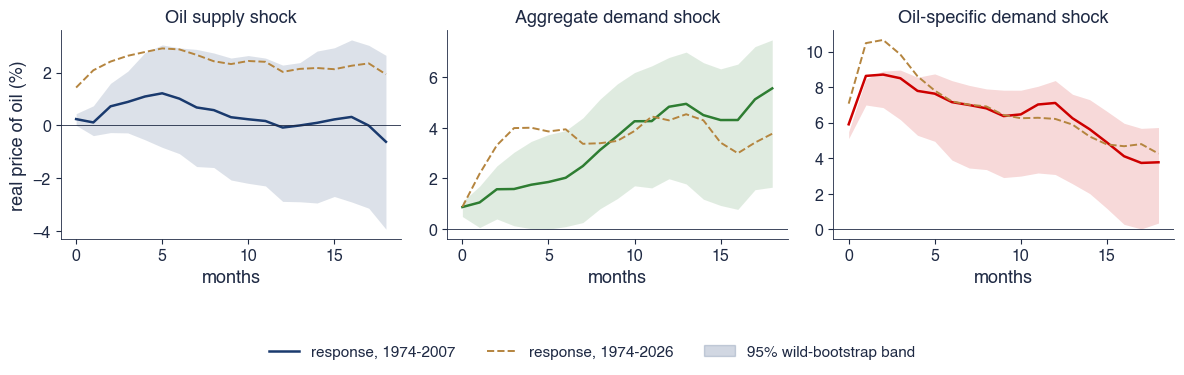

{'T': np.int64(384), 'p0': array([0.24, 0.86, 5.9 ]), 'p12': array([-0.08,  4.83,  7.11]), 'lo12': array([-2.88,  1.98,  3.08]), 'hi12': array([2.28, 6.78, 8.36]), 'p12_2': array([2.03, 4.29, 6.21]), 'fevd60': array([0.01, 0.64, 0.35]), 'fevd60_2': array([0.09, 0.31, 0.6 ])}


In [15]:
# Solution
r = b1_kilian(save_it=False, B=200)
print({k: np.round(v, 2) for k, v in r.items()})

**Interpretation of the result.** Demand shocks move the price; supply shocks matter more on the longer sample.

## B2 [Proposed]: orderings of a Romanian VAR

**Question.** Is the price puzzle after a ROBOR shock an artefact of the ordering or of the lag length? Model: B1.

1. Select the lag length by BIC and AIC.
2. Estimate three orderings for each lag length.
3. Report the responses of RO HICP, EUR/RON and RO IP to a 25 bp ROBOR shock.
4. Interpretation: what does the stability of the puzzle tell you?

**Report:** two lag lengths, a table of six rows, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: replicating Gertler and Karadi (2015)

**Question.** Does a monetary policy shock identified with FF4 surprises raise credit spreads and lower output?

1. Estimate the VAR and the first stage; report the robust $F$.
2. Compute the impact column (25 bp) and the responses.
3. Build 90% moving-block bootstrap bands.
4. Interpretation: through which channel does the shock work?

**Report:** one $F$, four impacts, the IP trough with its band, one sentence.

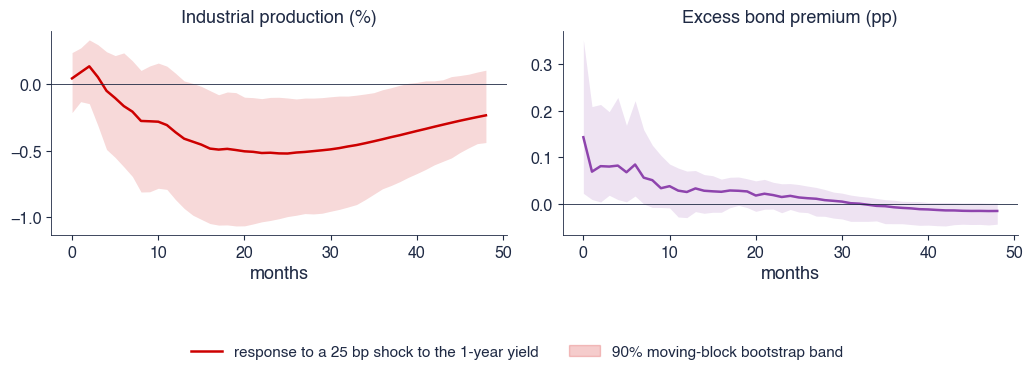

{'F': np.float64(17.722), 'F_hom': np.float64(21.88), 'b': np.float64(1.159), 'Tz': 258, 'imp': array([ 0.25 ,  0.042, -0.042,  0.143]), 'ip_min': np.float64(-0.522), 'ip_arg': 25, 'ip_lo': np.float64(-0.995), 'ip_hi': np.float64(-0.105), 'ebp0': np.float64(0.143), 'ebp0_lo': np.float64(0.022), 'ebp0_hi': np.float64(0.353)}


In [17]:
# Solution
r = b3_gk(save_it=False, B=200)
print({k: (np.round(v, 3) if not isinstance(v, int) else v) for k, v in r.items()})

**Interpretation of the result.** The excess bond premium jumps at once and output falls with a lag: the credit channel.

## B4 [Proposed]: Romer–Romer shocks by LP and by VAR

**Question.** Do local projections and a VAR with the same narrative shock give the same responses? Model: B3.

1. Estimate LP of IP, CPI and the funds rate on the shock.
2. Estimate a VAR(12) with the shock first.
3. Compare the IP trough, the CPI response after 48 months and the funds-rate impact.
4. Interpretation: which estimator would you report?

**Report:** three pairs of numbers, two SE, one sentence.

In [ ]:
# Your code here


## B5 [Proposed]: how robust is Blanchard–Quah?

**Question.** Does the share of demand shocks in output fluctuations survive changes in the treatment of low frequencies? Model: B1.

1. Estimate the BQ model with the original treatment.
2. Re-estimate without the break and the trend, and on data up to 2019.
3. Report the FEVD shares and the long-run supply effect.
4. Interpretation: what does this say about long-run restrictions?

**Report:** a table of three rows and four columns, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: euro-area spillovers with a weak instrument

**Question.** How much does Romanian HICP move 12 months after a 1 pp rise of the euro-area 1-year rate caused by an ECB policy shock? Model: B3.

1. Write a five-line pre-registration.
2. Estimate the LP-IV at $h = 12$; report $\hat\beta$, its SE and the first-stage $F$.
3. Build the 90% Anderson–Rubin set on a grid.
4. Interpretation: what can and cannot be concluded?

**Report:** a five-line plan, one estimate with SE, one $F$, one set, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) a four-variable SVAR needs four restrictions to be exactly identified;
- (b) in a Cholesky ordering, reordering the variables placed after the policy variable does not change the responses to the policy shock;
- (c) with enough horizons restricted, sign restrictions point-identify the output response;
- (d) in a proxy SVAR, b21/b11 equals Cov(u2, z)/Cov(u1, z);
- (e) local projections are unbiased and have smaller variance than VARs, so they always dominate;
- (f) the wild bootstrap of Mertens and Ravn gives valid bands for proxy SVARs;
- (g) with Sigma = [[4, 1], [1, 2]], the Cholesky impact of shock 1 on variable 2 is 1.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
